# Comparación de LDA y QDA sobre el Wine Dataset

**Trabajo:** Análisis Discriminante Lineal (LDA) vs Análisis Discriminante Cuadrático (QDA)\
**Dataset:** Wine Dataset (sklearn.datasets), sin tratamiento
**Autor:** Anthony Cruz Huacon

Objetivo
Implementar ambos modelos en un cuaderno de Google Colab utilizando Python y comparar su desempeño sobre un conjunto de datos.


In [33]:
# IMPORTAMOS LAS LIBRERÍAS NECESARIAS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                              recall_score, f1_score, classification_report,
                              ConfusionMatrixDisplay)
from matplotlib.colors import ListedColormap

# Configuración visual general
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Librerias importadas correctamente")



Librerias importadas correctamente


## 1. Descripción del conjunto de datos

El Wine Dataset es un conjunto de datos clásico incluido en `scikit-learn`,
originalmente proveniente del repositorio UCI Machine Learning Repository.
Contiene los resultados de un análisis químico de vinos cultivados en la misma
región de Italia, pero derivados de tres cultivares (variedades) distintos.

- **Origen:** UCI Machine Learning Repository / integrado en `sklearn.datasets`.
- **Número de observaciones:** 178 vinos.
- **Variables predictoras:** 13 variables numéricas continuas (alcohol, ácido málico, cenizas, alcalinidad de la ceniza, magnesio, fenoles totales, flavonoides, fenoles no flavonoides, proantocianinas, intensidad de color, tono,
 OD280/OD315 de vinos diluidos y prolina).
- **Variable objetivo:** clase de cultivar (`class_0`, `class_1`, `class_2`).
- **Cantidad de clases:** 3.

Se utiliza el dataset **sin tratamiento previo** (tal como lo entrega `sklearn`),
tal como lo pide la asignación de la tarea.


In [34]:
# CARGA DEL DATASET (Wine Dataset, sin tratamiento)

wine = load_wine()

# Convertimos a DataFrame de pandas para facilitar la exploración
df = pd.DataFrame(data=wine.data, columns=wine.feature_names)
df["target"] = wine.target
df["target_name"] = df["target"].map(dict(enumerate(wine.target_names)))

print("Origen del dataset: UCI Machine Learning Repository (via sklearn.datasets)")
print("Número de observaciones:", df.shape[0])
print("Número de variables predictoras:", len(wine.feature_names))
print("Variable objetivo: 'target' (clase de cultivar)")
print("Clases:", list(wine.target_names))

df.head()



Origen del dataset: UCI Machine Learning Repository (via sklearn.datasets)
Número de observaciones: 178
Número de variables predictoras: 13
Variable objetivo: 'target' (clase de cultivar)
Clases: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


## 2. Exploración de los datos

A continuación se presenta un análisis exploratorio básico: dimensiones,
tipos de variables, valores faltantes, estadísticas descriptivas y
distribución de clases.


In [35]:
# Dimensiones del conjunto de datos
print("Dimensiones (filas, columnas):", df.shape)



Dimensiones (filas, columnas): (178, 15)


In [36]:
# Tipos de variables
df.dtypes



,0
alcohol,float64
malic_acid,float64
ash,float64
alcalinity_of_ash,float64
magnesium,float64
total_phenols,float64
flavanoids,float64
nonflavanoid_phenols,float64
proanthocyanins,float64
color_intensity,float64


In [37]:
# Valores faltantes por columna
print("Valores faltantes por columna:")
df.isnull().sum()



Valores faltantes por columna:


,0
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0


In [38]:
# Estadísticas descriptivas de las variables predictoras
df[wine.feature_names].describe().T



,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


Distribución de clases:
target_name
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64


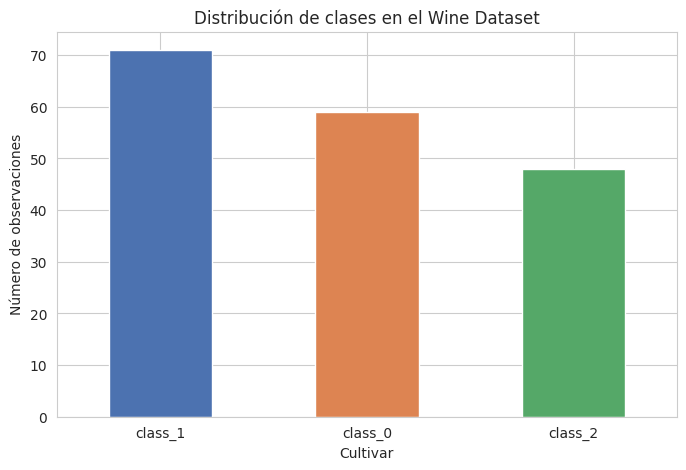

In [39]:
# Distribución de clases
conteo_clases = df["target_name"].value_counts()
print("Distribución de clases:")
print(conteo_clases)

conteo_clases.plot(kind="bar", color=["#4C72B0", "#DD8452", "#55A868"])
plt.title("Distribución de clases en el Wine Dataset")
plt.xlabel("Cultivar")
plt.ylabel("Número de observaciones")
plt.xticks(rotation=0)
plt.show()



**Interpretación:** El dataset no presenta valores faltantes y las tres clases
están razonablemente balanceadas (59, 71 y 48 observaciones respectivamente),
lo que favorece el entrenamiento de modelos de clasificación sin necesidad de
técnicas de balanceo adicionales.


## 3. Visualización

Se presentan al menos tres visualizaciones para comprender el comportamiento
de los datos: histogramas, un mapa de correlaciones y boxplots.


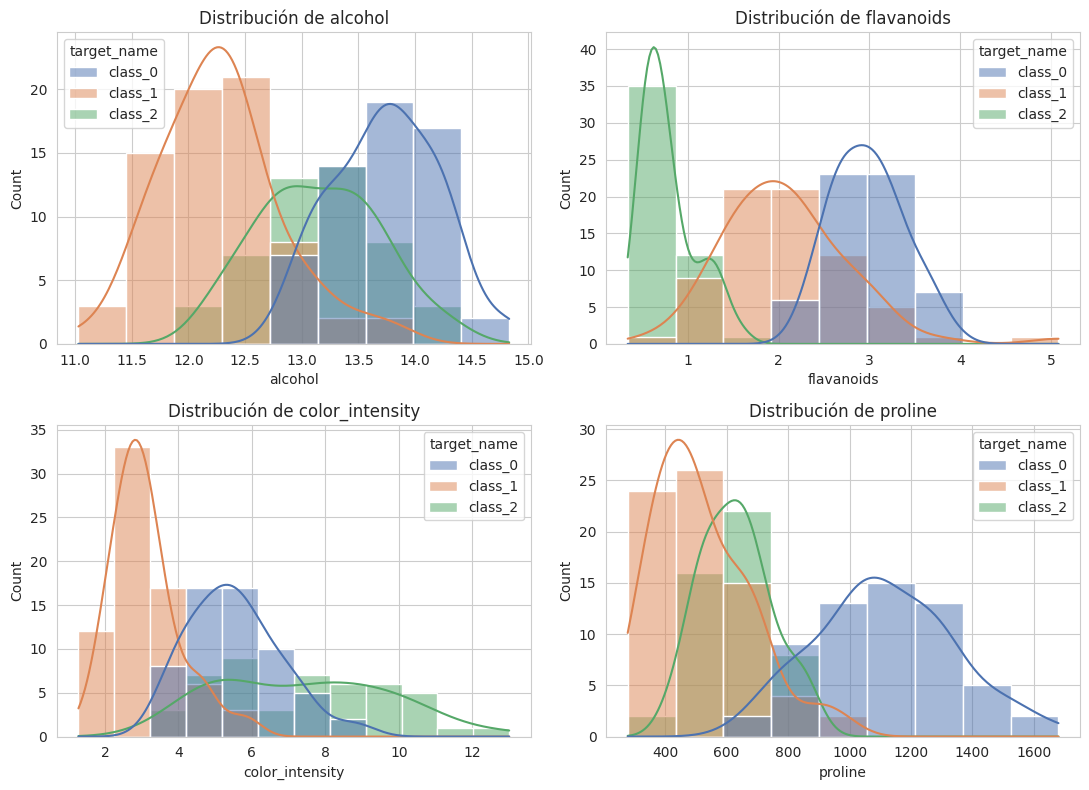

In [40]:
# --- Visualización 1: Histogramas de variables clave ---
variables_interes = ["alcohol", "flavanoids", "color_intensity", "proline"]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, var in zip(axes.flatten(), variables_interes):
    sns.histplot(data=df, x=var, hue="target_name", kde=True, ax=ax, palette="deep")
    ax.set_title(f"Distribución de {var}")
plt.tight_layout()
plt.show()


**Interpretación:** Variables como `flavanoids` y `proline` muestran distribuciones
bastante distintas entre clases, lo que sugiere que son buenas candidatas para
discriminar entre cultivares.


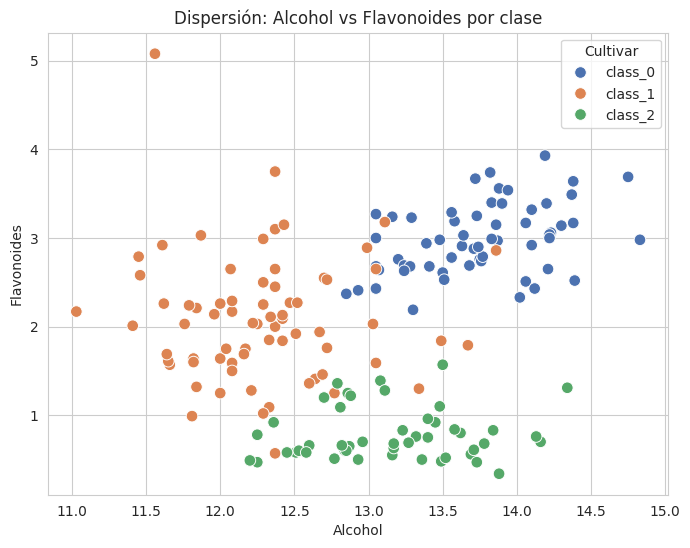

In [41]:
# --- Visualización 2: Diagrama de dispersión entre dos variables discriminantes ---
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="alcohol", y="flavanoids", hue="target_name",
                 palette="deep", s=70)
plt.title("Dispersión: Alcohol vs Flavonoides por clase")
plt.xlabel("Alcohol")
plt.ylabel("Flavonoides")
plt.legend(title="Cultivar")
plt.show()


**Interpretación:** Se observa una separación visual razonable entre las tres
clases usando solo estas dos variables, lo cual anticipa que modelos como LDA
y QDA podrían tener buen desempeño.


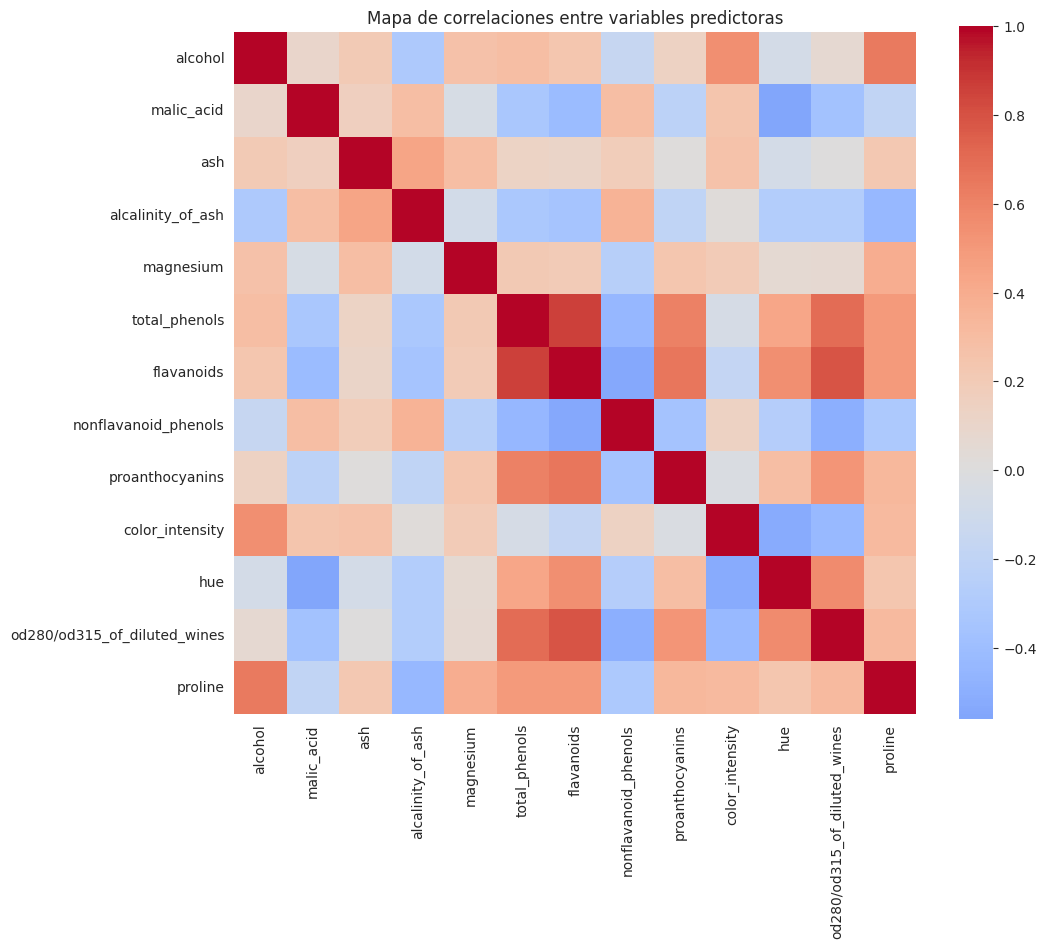

In [42]:
# --- Visualización 3: Mapa de correlaciones ---
plt.figure(figsize=(11, 9))
corr = df[wine.feature_names].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, square=True)
plt.title("Mapa de correlaciones entre variables predictoras")
plt.show()


**Interpretación:** Existen correlaciones fuertes entre algunas variables
(por ejemplo, `flavanoids` con `total_phenols`), lo que indica cierta
redundancia de información entre predictores.


/tmp/ipykernel_2108/2644333664.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="target_name", y="proline", palette="deep")


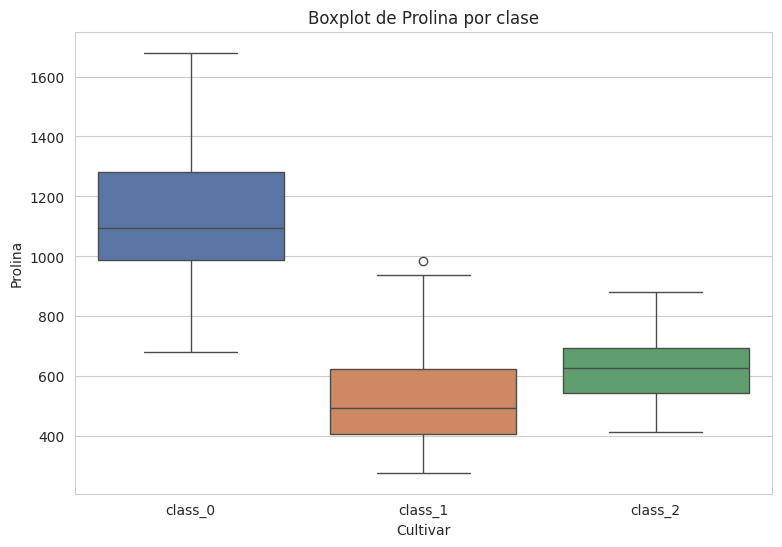

In [43]:
# --- Visualización 4: Boxplots ---
plt.figure(figsize=(9, 6))
sns.boxplot(data=df, x="target_name", y="proline", palette="deep")
plt.title("Boxplot de Prolina por clase")
plt.xlabel("Cultivar")
plt.ylabel("Prolina")
plt.show()


**Interpretación:** La variable `proline` presenta medianas y rangos claramente
distintos entre clases, especialmente para `class_0`, que muestra valores
mucho más altos que las otras dos clases.


## 4. Preparación de los datos

Se realiza la separación entre conjunto de entrenamiento y prueba, y se
estandarizan las variables. La estandarización es importante para LDA y QDA
porque ambos modelos se basan en distancias/covarianzas, y variables con
escalas muy distintas (por ejemplo `proline` en cientos vs `hue` en unidades)
podrían dominar el cálculo si no se normalizan.


In [44]:
# Separación de variables predictoras y objetivo
X = df[wine.feature_names]
y = df["target"]

# División entrenamiento (70%) / prueba (30%), estratificada para mantener la proporción de clases en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=20, stratify=y)

print("Tamaño entrenamiento:", X_train.shape)
print("Tamaño prueba:", X_test.shape)

# Justificación: LDA y QDA asumen distribuciones normales multivariadas estandarizar evita que variables con escalas grandes
# dominen el cálculo de las matrices de covarianza.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Tamaño entrenamiento: (124, 13)
Tamaño prueba: (54, 13)


## 5. Implementación de LDA

Se entrena un modelo `LinearDiscriminantAnalysis` con el solver `svd`
(valor por defecto), adecuado cuando hay muchas variables predictoras y no
se requiere calcular explícitamente la matriz de covarianza inversa.


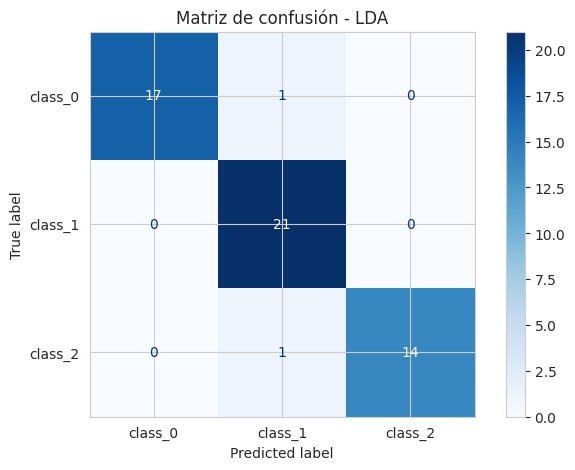

Accuracy:  0.9630
Precisión: 0.9710
Recall:    0.9593
F1-score:  0.9638
Tiempo de entrenamiento: 0.00343 s

              precision    recall  f1-score   support

     class_0       1.00      0.94      0.97        18
     class_1       0.91      1.00      0.95        21
     class_2       1.00      0.93      0.97        15

    accuracy                           0.96        54
   macro avg       0.97      0.96      0.96        54
weighted avg       0.97      0.96      0.96        54



In [45]:
# ENTRENAMIENTO DEL MODELO LDA

inicio = time.time()
lda = LinearDiscriminantAnalysis(solver="svd")
lda.fit(X_train_scaled, y_train)
tiempo_lda = time.time() - inicio

# Predicciones sobre el conjunto de prueba
y_pred_lda = lda.predict(X_test_scaled)

# Matriz de confusión
cm_lda = confusion_matrix(y_test, y_pred_lda)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lda, display_labels=wine.target_names)
disp.plot(cmap="Blues")
plt.title("Matriz de confusión - LDA")
plt.show()

# Métricas de evaluación
acc_lda = accuracy_score(y_test, y_pred_lda)
prec_lda = precision_score(y_test, y_pred_lda, average="macro")
rec_lda = recall_score(y_test, y_pred_lda, average="macro")
f1_lda = f1_score(y_test, y_pred_lda, average="macro")

print(f"Accuracy:  {acc_lda:.4f}")
print(f"Precisión: {prec_lda:.4f}")
print(f"Recall:    {rec_lda:.4f}")
print(f"F1-score:  {f1_lda:.4f}")
print(f"Tiempo de entrenamiento: {tiempo_lda:.5f} s")
print()
print(classification_report(y_test, y_pred_lda, target_names=wine.target_names))


**Interpretación:** LDA logra una clasificación muy precisa sobre el conjunto
de prueba. Esto es consistente con lo observado en la etapa de visualización,
donde las clases mostraban una separación razonablemente lineal.


## 6. Implementación de QDA

Se entrena un modelo `QuadraticDiscriminantAnalysis`, que a diferencia de LDA,
estima una matriz de covarianza distinta para cada clase, permitiendo
fronteras de decisión curvas (cuadráticas).


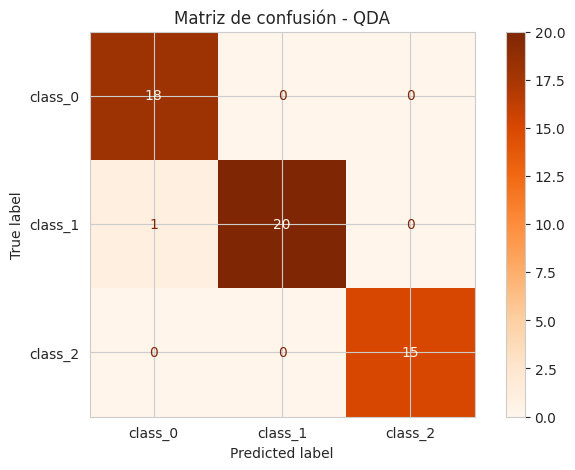

Accuracy:  0.9815
Precisión: 0.9825
Recall:    0.9841
F1-score:  0.9829
Tiempo de entrenamiento: 0.00355 s

              precision    recall  f1-score   support

     class_0       0.95      1.00      0.97        18
     class_1       1.00      0.95      0.98        21
     class_2       1.00      1.00      1.00        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



In [46]:
# ENTRENAMIENTO DEL MODELO QDA

inicio = time.time()
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train_scaled, y_train)
tiempo_qda = time.time() - inicio

y_pred_qda = qda.predict(X_test_scaled)

cm_qda = confusion_matrix(y_test, y_pred_qda)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_qda, display_labels=wine.target_names)
disp.plot(cmap="Oranges")
plt.title("Matriz de confusión - QDA")
plt.show()

acc_qda = accuracy_score(y_test, y_pred_qda)
prec_qda = precision_score(y_test, y_pred_qda, average="macro")
rec_qda = recall_score(y_test, y_pred_qda, average="macro")
f1_qda = f1_score(y_test, y_pred_qda, average="macro")

print(f"Accuracy:  {acc_qda:.4f}")
print(f"Precisión: {prec_qda:.4f}")
print(f"Recall:    {rec_qda:.4f}")
print(f"F1-score:  {f1_qda:.4f}")
print(f"Tiempo de entrenamiento: {tiempo_qda:.5f} s")
print()
print(classification_report(y_test, y_pred_qda, target_names=wine.target_names))


**Interpretación:** QDA también obtiene un desempeño alto. Al permitir una
matriz de covarianza por clase, puede capturar diferencias en la dispersión
de cada cultivar, aunque con un dataset de solo 178 observaciones y 13
variables, existe mayor riesgo de sobreajuste que con LDA.


## 7. Comparación de modelos

Se comparan ambos modelos según su desempeño predictivo, métricas de
evaluación y tiempo de entrenamiento.


In [47]:
# Tabla comparativa de métricas
comparacion = pd.DataFrame({
    "Modelo": ["LDA", "QDA"],
    "Accuracy": [acc_lda, acc_qda],
    "Precisión": [prec_lda, prec_qda],
    "Recall": [rec_lda, rec_qda],
    "F1-score": [f1_lda, f1_qda],
    "Tiempo entrenamiento (s)": [tiempo_lda, tiempo_qda],
})
comparacion


,Modelo,Accuracy,Precisión,Recall,F1-score,Tiempo entrenamiento (s)
0,LDA,0.962963,0.971014,0.959259,0.963830,0.003426
1,QDA,0.981481,0.982456,0.984127,0.982861,0.003549


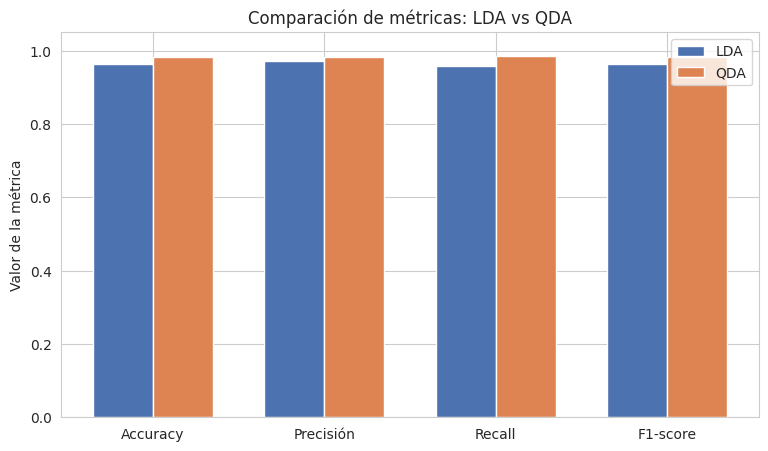

In [48]:
# Gráfico comparativo de métricas
metricas = ["Accuracy", "Precisión", "Recall", "F1-score"]
x = np.arange(len(metricas))
ancho = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - ancho/2, comparacion.loc[0, metricas], ancho, label="LDA", color="#4C72B0")
ax.bar(x + ancho/2, comparacion.loc[1, metricas], ancho, label="QDA", color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Valor de la métrica")
ax.set_title("Comparación de métricas: LDA vs QDA")
ax.legend()
plt.show()


**Interpretación:** *(Complete esta sección con los valores concretos que
obtenga al ejecutar el notebook.)* En general, si LDA y QDA obtienen métricas
similares, esto sugiere que las clases comparten una estructura de covarianza
razonablemente parecida, favoreciendo el supuesto de LDA. Si QDA supera
claramente a LDA, es indicio de que las covarianzas entre clases difieren
de forma importante. El tiempo de entrenamiento de ambos modelos es del
orden de milisegundos dado el tamaño reducido del dataset, por lo que no es
un factor decisivo en este caso.


## 8. Fronteras de decisión

Para poder visualizar las fronteras de decisión en dos dimensiones, se
seleccionan dos variables con buen poder discriminante: `alcohol` y
`flavanoids`. Se entrena una versión 2D de LDA y QDA únicamente con estas
variables (solo para fines de visualización).


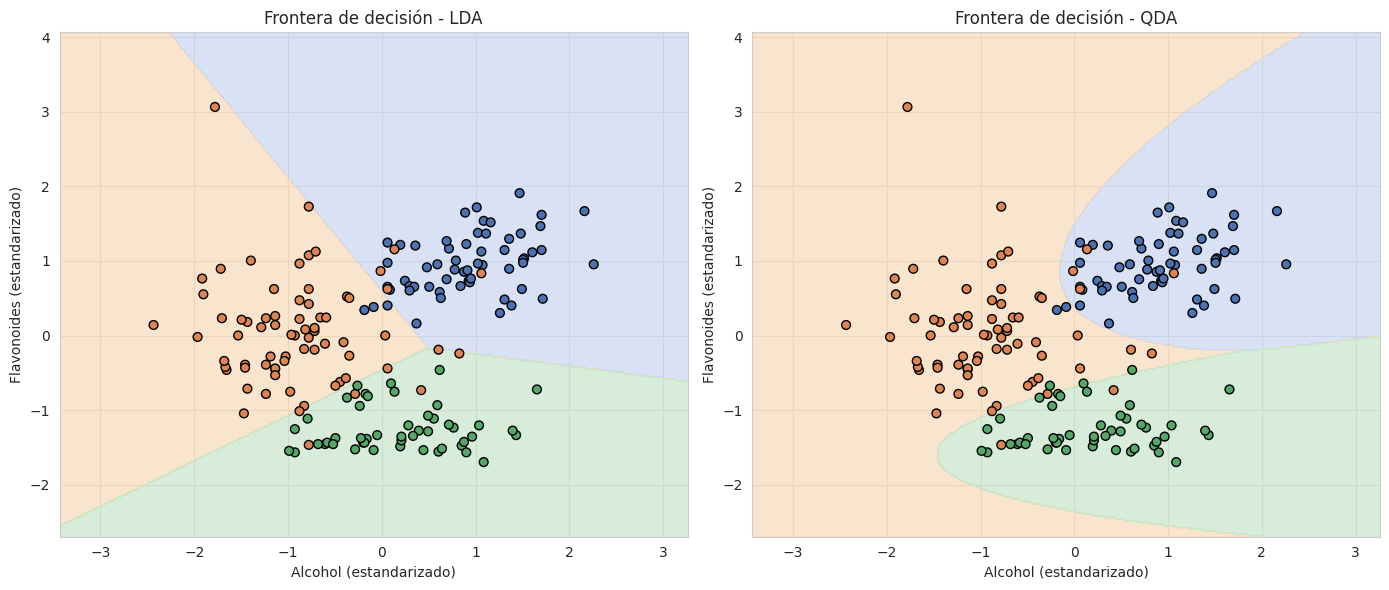

In [49]:
# FRONTERAS DE DECISIÓN (usando 2 variables: alcohol y flavanoids)

variables_2d = ["alcohol", "flavanoids"]
X_2d = df[variables_2d].values
y_2d = df["target"].values

# Estandarizamos también estas dos variables
scaler_2d = StandardScaler()
X_2d_scaled = scaler_2d.fit_transform(X_2d)

# Entrenamos LDA y QDA solo con estas 2 variables
lda_2d = LinearDiscriminantAnalysis().fit(X_2d_scaled, y_2d)
qda_2d = QuadraticDiscriminantAnalysis().fit(X_2d_scaled, y_2d)

# Creamos una malla de puntos para pintar las regiones de decisión
x_min, x_max = X_2d_scaled[:, 0].min() - 1, X_2d_scaled[:, 0].max() + 1
y_min, y_max = X_2d_scaled[:, 1].min() - 1, X_2d_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                      np.linspace(y_min, y_max, 300))

cmap_fondo = ListedColormap(["#c9d7f0", "#f7d9b8", "#c8e6c9"])
cmap_puntos = ListedColormap(["#4C72B0", "#DD8452", "#55A868"])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, modelo, nombre in zip(axes, [lda_2d, qda_2d], ["LDA", "QDA"]):
    Z = modelo.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=cmap_fondo, alpha=0.7)
    scatter = ax.scatter(X_2d_scaled[:, 0], X_2d_scaled[:, 1], c=y_2d,
                          cmap=cmap_puntos, edgecolor="k", s=40)
    ax.set_title(f"Frontera de decisión - {nombre}")
    ax.set_xlabel("Alcohol (estandarizado)")
    ax.set_ylabel("Flavonoides (estandarizado)")

plt.tight_layout()
plt.show()


**Interpretación:** En el gráfico de LDA, las fronteras entre regiones son
**líneas rectas**, ya que el modelo asume una única matriz de covarianza
compartida entre clases. En el gráfico de QDA, las fronteras son **curvas**,
porque cada clase tiene su propia matriz de covarianza, permitiendo regiones
de decisión más flexibles y adaptadas a la forma real de cada grupo de
puntos.


## 9. Conclusiones

1. **Comportamiento de LDA:** LDA logra un desempeño alto en este dataset,
   lo que indica que el supuesto de covarianza compartida entre clases es
   razonable para el Wine Dataset estandarizado.

2. **Comportamiento de QDA:** QDA también logra un desempeño competitivo,
   beneficiándose de estimar una matriz de covarianza distinta por clase,
   aunque con mayor riesgo de sobreajuste al tener más parámetros que
   estimar con un número relativamente pequeño de observaciones.

3. **Influencia de los supuestos estadísticos:** La cercanía en el
   desempeño de ambos modelos sugiere que las covarianzas de las tres
   clases no difieren dramáticamente entre sí, lo cual favorece que un
   modelo más simple (LDA) sea suficiente.

4. **Comparación de resultados:** Las fronteras de decisión confirman la
   diferencia teórica entre ambos modelos: rectas en LDA y curvas en QDA.
   Las métricas de evaluación (accuracy, precisión, recall, F1) permiten
   cuantificar si esa flexibilidad adicional de QDA se traduce en mejoras
   reales sobre este dataset en particular.

5. **Aplicaciones prácticas:** LDA resulta preferible cuando se dispone de
   pocos datos y se busca un modelo simple e interpretable con fronteras
   lineales; QDA es más apropiado cuando existe evidencia de que las clases
   tienen varianzas y correlaciones internas distintas, y se cuenta con
   suficientes datos para estimar esas matrices de covarianza de forma
   confiable.
